[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


(6896, 13)
   page_id                         name                              urlslug  \
0     1422         Batman (Bruce Wayne)         \/wiki\/Batman_(Bruce_Wayne)   
1    23387        Superman (Clark Kent)        \/wiki\/Superman_(Clark_Kent)   
2     1458   Green Lantern (Hal Jordan)   \/wiki\/Green_Lantern_(Hal_Jordan)   
3     1659     James Gordon (New Earth)     \/wiki\/James_Gordon_(New_Earth)   
4     1576  Richard Grayson (New Earth)  \/wiki\/Richard_Grayson_(New_Earth)   

                ID            ALIGN         EYE        HAIR              SEX  \
0  Secret Identity  Good Characters   Blue Eyes  Black Hair  Male Characters   
1  Secret Identity  Good Characters   Blue Eyes  Black Hair  Male Characters   
2  Secret Identity  Good Characters  Brown Eyes  Brown Hair  Male Characters   
3  Public Identity  Good Characters  Brown Eyes  White Hair  Male Characters   
4  Secret Identity  Good Characters   Blue Eyes  Black Hair  Male Characters   

   GSM              ALIVE  

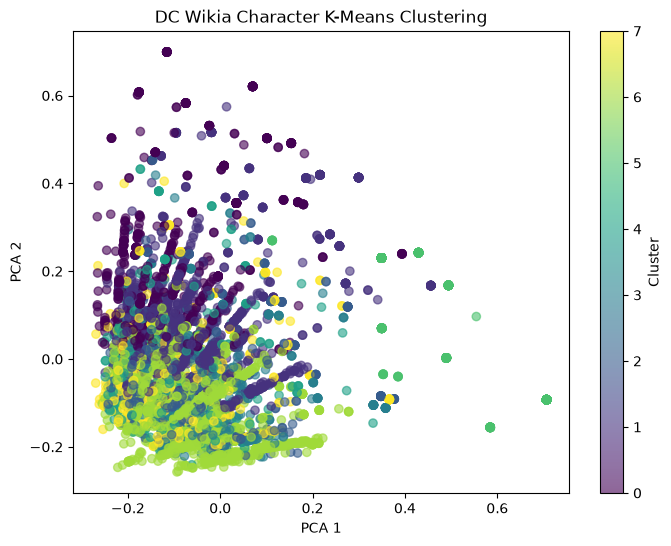


Done! Saved: dc-wikia-clustered.csv


In [1]:
# 1. IMPORTS
import pandas as pd
import re
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import nltk
nltk.download("stopwords")
nltk.download("wordnet")

# 2. LOAD DATA
df = pd.read_csv("dc-wikia-data.csv")
print(df.shape)
print(df.head())

# 3. CREATE TEXT FROM AVAILABLE COLUMNS
cols = [c for c in ["name", "Name", "IDENTITY", "ALIGN", "EYE", "HAIR", "SEX"]
        if c in df.columns]

df["text"] = df[cols].fillna("").astype(str).agg(" ".join, axis=1)

# 4. NLP CLEANING
stop = set(stopwords.words("english"))
lemma = WordNetLemmatizer()

def clean(x):
    x = re.sub(r"[^a-zA-Z\s]", " ", x.lower())
    return " ".join(
        lemma.lemmatize(w) for w in x.split()
        if w not in stop and len(w) > 2
    )

df["clean_text"] = df["text"].apply(clean)

# 5. TF-IDF
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df["clean_text"])

# 6. FIND BEST K
scores = {}

for k in range(2, 10):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    scores[k] = silhouette_score(X, labels)

best_k = max(scores, key=scores.get)
print("Best K:", best_k)

# 7. K-MEANS
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)

print("\nSilhouette Score:", silhouette_score(X, df["Cluster"]))
print(df["Cluster"].value_counts())

# 8. SHOW CLUSTERS
for c in sorted(df["Cluster"].unique()):
    print(f"\nCLUSTER {c}")
    print(df[df["Cluster"] == c][cols].head(10))

# 9. PCA VISUALISATION
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df["Cluster"], alpha=0.6)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("DC Wikia Character K-Means Clustering")
plt.colorbar(label="Cluster")
plt.show()

# 10. SAVE RESULT
df.to_csv("dc-wikia-clustered.csv", index=False)

print("\nDone! Saved: dc-wikia-clustered.csv")